In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
data = pd.read_json(url)

data.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


data.shape

In [2]:
data = pd.json_normalize(data.to_dict(orient='records'))

In [3]:
data.shape

(7267, 21)

In [4]:
data

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [5]:
data.columns = data.columns.str.split('.').str[-1]

In [6]:
data.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total'],
      dtype='str')

In [7]:
import numpy as np
data['Total'] = pd.to_numeric(data['Total'], errors='coerce')

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   str    
 1   Churn             7267 non-null   str    
 2   gender            7267 non-null   str    
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   str    
 5   Dependents        7267 non-null   str    
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   str    
 8   MultipleLines     7267 non-null   str    
 9   InternetService   7267 non-null   str    
 10  OnlineSecurity    7267 non-null   str    
 11  OnlineBackup      7267 non-null   str    
 12  DeviceProtection  7267 non-null   str    
 13  TechSupport       7267 non-null   str    
 14  StreamingTV       7267 non-null   str    
 15  StreamingMovies   7267 non-null   str    
 16  Contract          7267 non-null   str    
 17  Paperl

In [9]:
data.isnull().sum()

customerID           0
Churn                0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
Monthly              0
Total               11
dtype: int64

In [10]:
data.describe()

,SeniorCitizen,tenure,Monthly,Total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
data['Total'] = data['Total'].fillna(data['Total'].median())

In [12]:
data.isnull().sum()

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64

In [13]:
for col in data.select_dtypes(include='str'):
    print(col)
    print(data[col].unique())
    print()


customerID
<StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str

Churn
<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str

gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

PhoneService
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

MultipleLines
<StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str

InternetService
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DevicePr

In [14]:
data['Churn'].value_counts()

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

In [15]:
data['Churn'] = data['Churn'].replace('', pd.NA)

In [16]:
data.isna().sum()

customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Monthly               0
Total                 0
dtype: int64

In [17]:
data = data.dropna(subset=['Churn'])

In [18]:
data['Churn'].isna().sum()

np.int64(0)

In [19]:
data.duplicated().sum()

np.int64(0)

In [20]:
data['customerID'].duplicated().sum()

np.int64(0)

In [21]:
data.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
5303,7244-KXYZN,No,Female,0,No,No,24,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),20.45,527.35
6364,8748-HFWBO,No,Male,0,Yes,Yes,19,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,19.90,357.70
4634,6349-JDHQP,No,Female,0,No,No,53,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.85,1049.60
1537,2205-LPVGL,No,Male,1,Yes,Yes,58,Yes,Yes,Fiber optic,...,Yes,No,Yes,No,No,One year,Yes,Bank transfer (automatic),89.85,5125.75
3271,4565-EVZMJ,No,Female,0,No,No,47,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Mailed check,58.90,2813.05


In [22]:
for col in data.select_dtypes(include='str'):
    if col != 'customerID':
        data[col] = data[col].str.lower().str.strip()

In [23]:
data

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.60,593.30
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.90,542.40
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.90,280.85
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.00,1237.85
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,no,female,0,no,no,13,yes,no,dsl,...,no,no,yes,no,no,one year,no,mailed check,55.15,742.90
7263,9992-RRAMN,yes,male,0,yes,no,22,yes,yes,fiber optic,...,no,no,no,no,yes,month-to-month,yes,electronic check,85.10,1873.70
7264,9992-UJOEL,no,male,0,no,no,2,yes,no,dsl,...,yes,no,no,no,no,month-to-month,yes,mailed check,50.30,92.75
7265,9993-LHIEB,no,male,0,yes,yes,67,yes,no,dsl,...,no,yes,yes,no,yes,two year,no,mailed check,67.85,4627.65


In [24]:
data['Cuentas_Diarias'] = round(data['Monthly'] / 30, 2)

In [25]:
data

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Cuentas_Diarias
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,no,yes,yes,no,one year,yes,mailed check,65.60,593.30,2.19
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,no,mailed check,59.90,542.40,2.00
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,yes,electronic check,73.90,280.85,2.46
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,yes,mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,no,female,0,no,no,13,yes,no,dsl,...,no,yes,no,no,one year,no,mailed check,55.15,742.90,1.84
7263,9992-RRAMN,yes,male,0,yes,no,22,yes,yes,fiber optic,...,no,no,no,yes,month-to-month,yes,electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,no,male,0,no,no,2,yes,no,dsl,...,no,no,no,no,month-to-month,yes,mailed check,50.30,92.75,1.68
7265,9993-LHIEB,no,male,0,yes,yes,67,yes,no,dsl,...,yes,yes,no,yes,two year,no,mailed check,67.85,4627.65,2.26


In [26]:
cols_binarias = [
    'Churn','Partner','Dependents','PhoneService','PaperlessBilling'
]

In [27]:
for col in cols_binarias:
    data[col] = data[col].map({'yes':1, 'no':0})



data['gender'] = data['gender'].map({'female':0, 'male':1})

In [28]:
data

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,1,no,dsl,...,no,yes,yes,no,one year,1,mailed check,65.60,593.30,2.19
1,0003-MKNFE,0,1,0,0,0,9,1,yes,dsl,...,no,no,no,yes,month-to-month,0,mailed check,59.90,542.40,2.00
2,0004-TLHLJ,1,1,0,0,0,4,1,no,fiber optic,...,yes,no,no,no,month-to-month,1,electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,1,1,1,0,13,1,no,fiber optic,...,yes,no,yes,yes,month-to-month,1,electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,0,1,1,0,3,1,no,fiber optic,...,no,yes,yes,no,month-to-month,1,mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,0,0,0,0,13,1,no,dsl,...,no,yes,no,no,one year,0,mailed check,55.15,742.90,1.84
7263,9992-RRAMN,1,1,0,1,0,22,1,yes,fiber optic,...,no,no,no,yes,month-to-month,1,electronic check,85.10,1873.70,2.84
7264,9992-UJOEL,0,1,0,0,0,2,1,no,dsl,...,no,no,no,no,month-to-month,1,mailed check,50.30,92.75,1.68
7265,9993-LHIEB,0,1,0,1,1,67,1,no,dsl,...,yes,yes,no,yes,two year,0,mailed check,67.85,4627.65,2.26


In [29]:
data = data.drop(columns=['customerID'])

In [30]:
cols = [
'MultipleLines',
'InternetService',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies',
'Contract',
'PaymentMethod'
]

data = pd.get_dummies(data, columns=cols, drop_first=True)

In [31]:
data

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Monthly,Total,...,TechSupport_yes,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,0,0,1,1,9,1,1,65.60,593.30,...,True,False,True,False,False,True,False,False,False,True
1,0,1,0,0,0,9,1,0,59.90,542.40,...,False,False,False,False,True,False,False,False,False,True
2,1,1,0,0,0,4,1,1,73.90,280.85,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,1,0,13,1,1,98.00,1237.85,...,False,False,True,False,True,False,False,False,True,False
4,1,0,1,1,0,3,1,1,83.90,267.40,...,True,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,1,0,55.15,742.90,...,True,False,False,False,False,True,False,False,False,True
7263,1,1,0,1,0,22,1,1,85.10,1873.70,...,False,False,False,False,True,False,False,False,True,False
7264,0,1,0,0,0,2,1,1,50.30,92.75,...,False,False,False,False,False,False,False,False,False,True
7265,0,1,0,1,1,67,1,0,67.85,4627.65,...,True,False,False,False,True,False,True,False,False,True


In [32]:
data = data.astype(int)

In [ ]:
data

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Monthly,Total,...,TechSupport_yes,StreamingTV_no internet service,StreamingTV_yes,StreamingMovies_no internet service,StreamingMovies_yes,Contract_one year,Contract_two year,PaymentMethod_credit card (automatic),PaymentMethod_electronic check,PaymentMethod_mailed check
0,0,0,0,1,1,9,1,1,65,593,...,1,0,1,0,0,1,0,0,0,1
1,0,1,0,0,0,9,1,0,59,542,...,0,0,0,0,1,0,0,0,0,1
2,1,1,0,0,0,4,1,1,73,280,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1,1,0,13,1,1,98,1237,...,0,0,1,0,1,0,0,0,1,0
4,1,0,1,1,0,3,1,1,83,267,...,1,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,1,0,55,742,...,1,0,0,0,0,1,0,0,0,1
7263,1,1,0,1,0,22,1,1,85,1873,...,0,0,0,0,1,0,0,0,1,0
7264,0,1,0,0,0,2,1,1,50,92,...,0,0,0,0,0,0,0,0,0,1
7265,0,1,0,1,1,67,1,0,67,4627,...,1,0,0,0,1,0,1,0,0,1


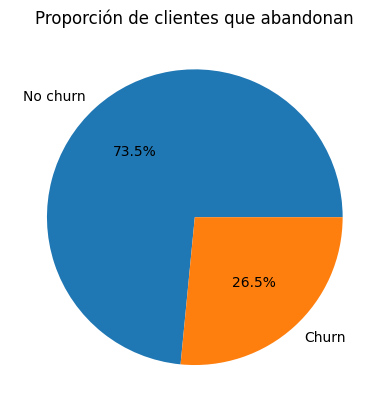

In [34]:
import matplotlib.pyplot as plt
data['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No churn','Churn']
)

plt.title('Proporción de clientes que abandonan')
plt.ylabel('')
plt.show()

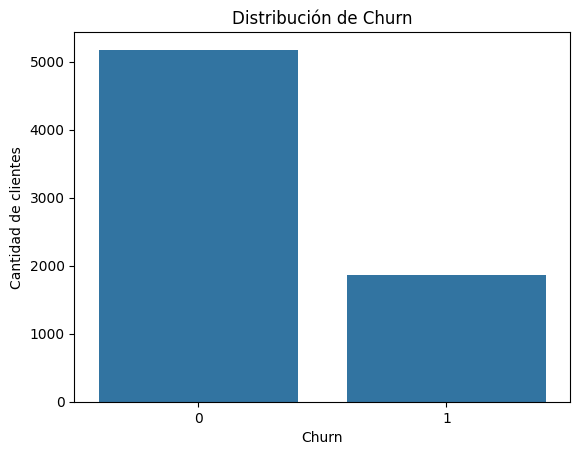

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn', data=data)

plt.title('Distribución de Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de clientes')
plt.show()

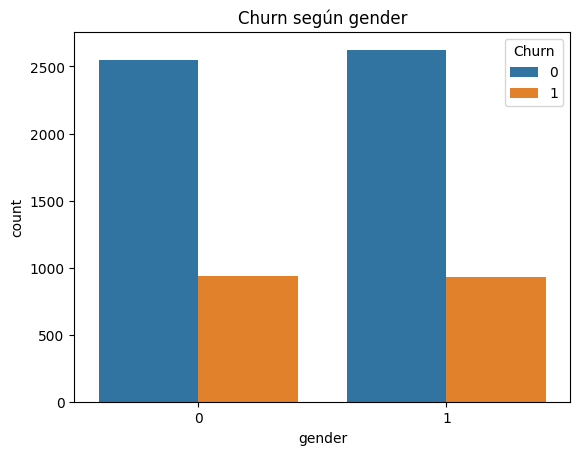

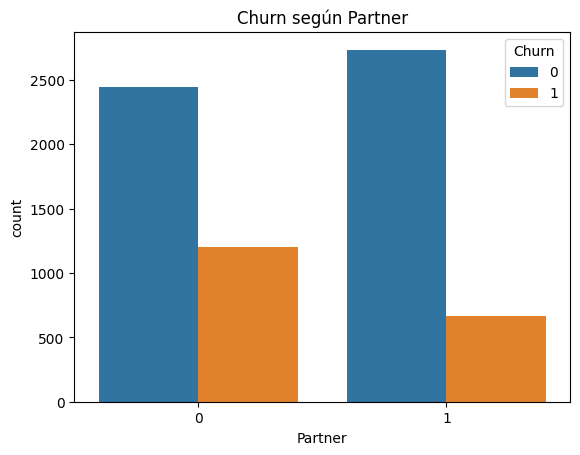

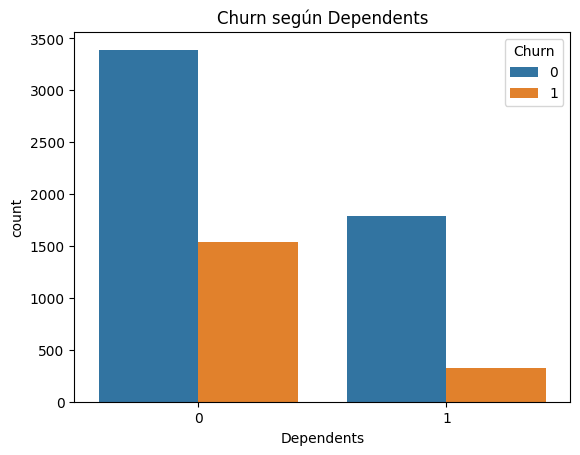

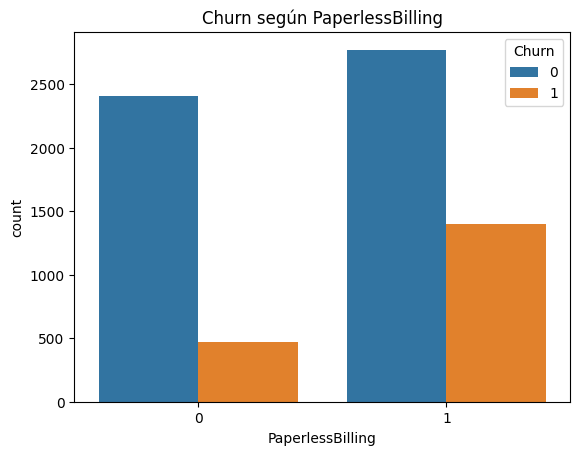

In [39]:
cols = ['gender','Partner','Dependents','PaperlessBilling']

for col in cols:
    sns.countplot(x=col, hue='Churn', data=data)
    plt.title(f'Churn según {col}')
    plt.show()

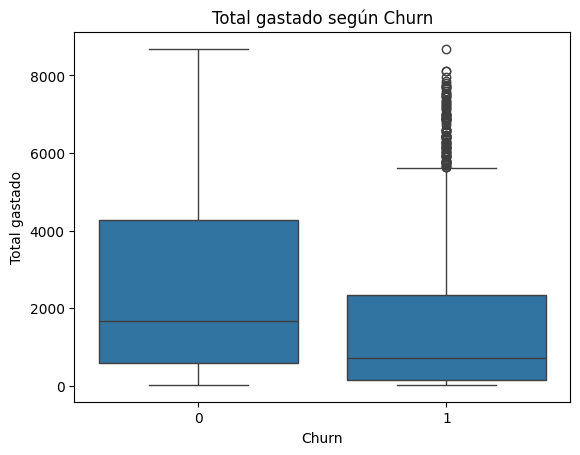

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='Total', data=data)

plt.title('Total gastado según Churn')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()

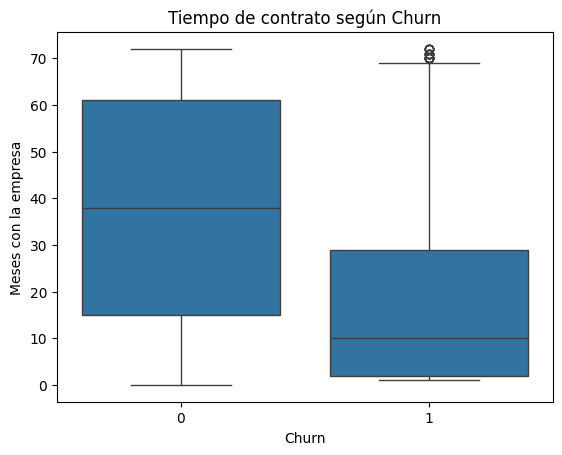

In [41]:
sns.boxplot(x='Churn', y='tenure', data=data)

plt.title('Tiempo de contrato según Churn')
plt.xlabel('Churn')
plt.ylabel('Meses con la empresa')
plt.show()

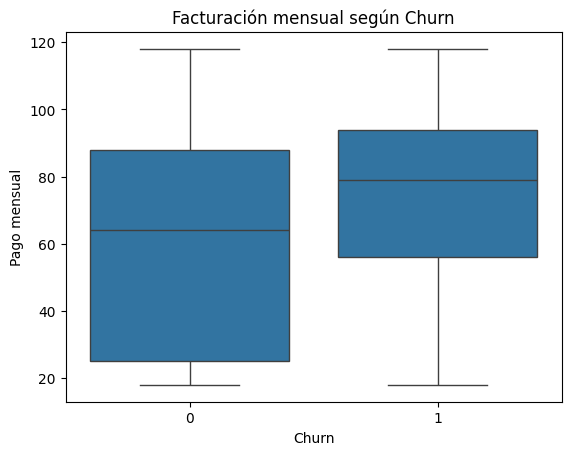

In [42]:
sns.boxplot(x='Churn', y='Monthly', data=data)

plt.title('Facturación mensual según Churn')
plt.xlabel('Churn')
plt.ylabel('Pago mensual')
plt.show()